In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl textblob transformers torch -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\mp2pf\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# =============================================================================
# CELL 1: INSTALL & IMPORT LIBRARY
# =============================================================================

# # Install required libraries
# print("📦 Installing required libraries...")
# !pip install xgboost openpyxl textblob -q
# print("✅ Installation complete!\n")

# Import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import library Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

# Import library NLP untuk Semantic Sentiment Analysis
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

# Import untuk Excel Report
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows
from datetime import datetime

# Import untuk sentiment analysis tambahan
from textblob import TextBlob

# Matikan warning
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("✅ Semua library berhasil di-import!")
print("=" * 60)
print(f"🔧 PyTorch version: {torch.__version__}")
print(f"🖥️  Device: {'CUDA (GPU) ✅' if torch.cuda.is_available() else 'CPU ⚠️'}")
print(f"📊 Pandas version: {pd.__version__}")
print(f"🤖 XGBoost version: {XGBClassifier.__module__}")
print("=" * 60)

C:\Users\mp2pf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Semua library berhasil di-import!
🔧 PyTorch version: 2.11.0+cpu
🖥️  Device: CPU ⚠️
📊 Pandas version: 3.0.2
🤖 XGBoost version: xgboost.sklearn


In [3]:
# =============================================================================
# CELL 2: LOAD DATA
# =============================================================================

# Load data
df = pd.read_csv('churn_data.csv')

print(f"📊 Shape of dataset: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")
print("\n🔍 Preview Data:")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'churn_data.csv'

In [ ]:
# =============================================================================
# CELL 3: DATA CLEANING & PREPROCESSING
# =============================================================================

# 1. Simpan data asli untuk referensi di report nanti
df_original = df.copy()

# 2. Menangani nilai yang tidak wajar (string error)
df.replace({'?': np.nan, 'Unknown': np.nan, 'Error': np.nan}, inplace=True)

# =============================================================================
# 🔥 3. HANDLE OUTLIERS & INVALID VALUES (TAMBAHAN PENTING)
# =============================================================================

# Konversi kolom numerik (paksa string → angka, error jadi NaN)
cols_to_convert = [
    'days_since_last_login',
    'avg_session_duration',
    'avg_frequency_login_days',
    'points_in_wallet',
    'session_minutes_90d'
]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- days_since_last_login ---
df.loc[df['days_since_last_login'] < 0, 'days_since_last_login'] = np.nan

# --- avg_session_duration ---
df.loc[(df['avg_session_duration'] < 0) |
       (df['avg_session_duration'] > 10000), 'avg_session_duration'] = np.nan

# --- avg_frequency_login_days ---
df.loc[(df['avg_frequency_login_days'] < 0) |
       (df['avg_frequency_login_days'] > 365), 'avg_frequency_login_days'] = np.nan

# --- points_in_wallet ---
df.loc[(df['points_in_wallet'] < 0) |
       (df['points_in_wallet'] > 1_000_000), 'points_in_wallet'] = np.nan

# --- session_minutes_90d ---
df.loc[df['session_minutes_90d'] > 130000, 'session_minutes_90d'] = np.nan


# =============================================================================
# 4. Feature Selection (Hapus fitur yang tidak relevan)
# =============================================================================
cols_to_drop = ['security_no', 'referral_id', 'last_visit_time']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# =============================================================================
# 5. Transformasi Tanggal
# =============================================================================
df['joining_date'] = pd.to_datetime(df['joining_date'], format='%d-%m-%Y', errors='coerce')
reference_date = pd.to_datetime('2018-01-01')
df['days_since_joined'] = (reference_date - df['joining_date']).dt.days
df.drop('joining_date', axis=1, inplace=True)

# =============================================================================
# 6. Simpan kolom feedback untuk NLP
# =============================================================================
feedback_data = df['feedback'].fillna('').astype(str).copy()

# =============================================================================
# 7. Handling Missing Values
# =============================================================================
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if col != 'feedback':
        df[col] = df[col].fillna(df[col].mode()[0])

# =============================================================================
# 8. EXPORT HASIL PREPROCESSING
# =============================================================================

# Simpan dataset yang sudah dibersihkan
df.to_csv('cleaned_churn_data.csv', index=False)

print("💾 Data berhasil disimpan:")
print("- cleaned_churn_data.csv")

# =============================================================================
# DONE
# =============================================================================
print("✅ Data Cleaning + Outlier Handling Selesai!")
print(f"📊 Total baris: {len(df)}")
print(f"📋 Total kolom: {len(df.columns)}")

💾 Data berhasil disimpan:
- cleaned_churn_data.csv
✅ Data Cleaning + Outlier Handling Selesai!
📊 Total baris: 36992
📋 Total kolom: 25


In [ ]:
# =============================================================================
# CELL 4: ADAPTIVE SEMANTIC SENTIMENT ANALYSIS
# - Cocok untuk feedback yang berupa label kategorikal + teks bebas
# - Lebih variatif, lebih valid, dan tetap adjustable
# =============================================================================

from textblob import TextBlob
import numpy as np
import re
import time

class AdaptiveSentimentAnalyzer:
    """
    Sentiment analyzer hybrid:
    1) Label-aware mapping untuk dataset yang feedback-nya berupa kategori tetap
    2) Keyword/phrase scoring
    3) TextBlob polarity fallback untuk teks bebas
    4) Adjustable threshold & bobot
    """

    def __init__(
        self,
        label_weight=0.60,
        phrase_weight=0.25,
        polarity_weight=0.15,
        neutral_band=0.30,
        score_smoothing=0.20,
        use_dynamic_threshold=False
    ):
        print("✅ Adaptive Sentiment Analyzer Ready!")

        # =========================
        # ADJUSTABLE PARAMETERS
        # =========================
        self.label_weight = label_weight
        self.phrase_weight = phrase_weight
        self.polarity_weight = polarity_weight
        self.neutral_band = neutral_band
        self.score_smoothing = score_smoothing
        self.use_dynamic_threshold = use_dynamic_threshold

        # =========================
        # DATASET-SPECIFIC LABEL MAP
        # (disesuaikan dengan nilai unik feedback yang kamu kirim)
        # =========================
        # Skala base score: -2.0 s/d +2.0
        self.label_score_map = {
            "poor product quality": -1.90,
            "poor website": -1.55,
            "poor customer service": -1.75,
            "too many ads": -1.05,
            "no reason specified": 0.00,
            "reasonable price": 0.85,
            "user friendly website": 1.15,
            "products always in stock": 1.45,
            "quality customer care": 1.30,
        }

        # Untuk phrase matching yang lebih fleksibel
        self.very_positive_phrases = {
            "excellent", "amazing", "fantastic", "outstanding", "perfect",
            "love", "best", "wonderful", "great", "awesome", "superb",
            "highly recommend", "very happy", "very satisfied", "exceeded",
            "brilliant", "exceptional", "delighted", "impressed", "magnificent",
            "5 star", "five star", "loved it", "incredible", "phenomenal",
            "sangat bagus", "bagus sekali", "sangat puas", "puas sekali",
            "luar biasa", "mantap", "keren banget", "top banget", "recommended banget"
        }

        self.positive_phrases = {
            "good", "nice", "happy", "satisfied", "helpful", "friendly",
            "recommend", "pleased", "enjoy", "thanks", "appreciate",
            "fine", "decent", "pleasant", "quick", "easy", "smooth",
            "reliable", "quality", "professional", "efficient",
            "bagus", "oke", "lumayan", "puas", "ramah", "cepat",
            "mudah", "nyaman", "bagus juga", "cukup bagus", "worth it"
        }

        self.negative_phrases = {
            "bad", "poor", "disappointed", "unhappy", "problem", "issue",
            "slow", "difficult", "frustrating", "annoying", "delay",
            "confusing", "expensive", "complicated", "waiting", "annoyed",
            "unsatisfied", "mediocre", "lacking", "subpar",
            "jelek", "kurang bagus", "lama", "ribet", "mahal",
            "kecewa", "tidak puas", "buruk", "error", "lemot", "boros"
        }

        self.very_negative_phrases = {
            "terrible", "horrible", "worst", "awful", "hate", "angry",
            "unacceptable", "never again", "very disappointed", "waste",
            "scam", "fraud", "disgusting", "pathetic", "useless",
            "ridiculous", "incompetent", "nightmare", "disaster", "appalling",
            "1 star", "one star", "refused", "cancel",
            "parah", "buruk sekali", "kecewa banget", "sangat mengecewakan",
            "sampah", "kapok", "tidak rekomendasi", "penipuan", "gak guna",
            "nggak guna", "gak membantu", "gagal total"
        }

        # Intensifier / negation
        self.intensifiers = {
            "very", "really", "extremely", "super", "highly",
            "sangat", "banget", "sekali", "amat"
        }

        self.negations = {
            "not", "no", "never", "none", "without",
            "tidak", "tak", "gak", "nggak", "bukan", "jangan"
        }

        # Threshold kategori final
        # Bisa kamu ubah kalau hasil masih terlalu berat ke tengah
        self.thresholds = {
            "sangat_puas": 1.00,
            "puas": 0.25,
            "biasa": -0.25,
            "kecewa": -1.00
        }

    def normalize_text(self, text):
        """Normalisasi teks agar matching lebih stabil"""
        text = str(text).lower().strip()
        text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def count_phrases(self, text_lower):
        """Hitung kemunculan phrase sentiment"""
        very_pos = sum(1 for p in self.very_positive_phrases if p in text_lower)
        pos = sum(1 for p in self.positive_phrases if p in text_lower)
        neg = sum(1 for p in self.negative_phrases if p in text_lower)
        very_neg = sum(1 for p in self.very_negative_phrases if p in text_lower)
        return very_pos, pos, neg, very_neg

    def detect_intensity(self, text_lower):
        """Deteksi intensifier dan negation ringan"""
        intensity_hits = sum(1 for w in self.intensifiers if w in text_lower)
        negation_hits = sum(1 for w in self.negations if w in text_lower)
        return intensity_hits, negation_hits

    def get_label_base_score(self, text_lower):
        """
        Ambil base score dari label dataset.
        Kalau teks bukan label persis, tetap coba matching sebagian.
        """
        if text_lower in self.label_score_map:
            return self.label_score_map[text_lower]

        # Partial match untuk variasi teks yang masih mengandung label inti
        for label, score in self.label_score_map.items():
            if label in text_lower:
                return score

        return None  # tidak ketemu label dataset

    def score_text(self, text):
        """Menghasilkan score sentimen final (range kira-kira -2 s/d +2)"""

        # Handle null / kosong
        if text is None:
            return 0.0, "Biasa", 3, 0.50

        if isinstance(text, float) and np.isnan(text):
            return 0.0, "Biasa", 3, 0.50

        text_str = str(text).strip()
        if text_str == "" or text_str.lower() == "nan":
            return 0.0, "Biasa", 3, 0.50

        text_norm = self.normalize_text(text_str)

        # 1) Base score dari label dataset
        label_base = self.get_label_base_score(text_norm)

        # 2) Phrase score
        very_pos, pos, neg, very_neg = self.count_phrases(text_norm)
        intensity_hits, negation_hits = self.detect_intensity(text_norm)

        phrase_score = (very_pos * 2.0) + (pos * 1.0) - (neg * 1.0) - (very_neg * 2.0)

        # 3) Polarity TextBlob
        try:
            polarity = TextBlob(text_str).sentiment.polarity
        except:
            polarity = 0.0

        # 4) Adjustments
        # intensifier memberi sedikit boost
        phrase_score += intensity_hits * 0.35

        # jika ada negation, kurangi kekuatan arah skor
        if negation_hits > 0:
            phrase_score *= 0.80
            polarity *= 0.80

        # 5) Gabungkan semua sumber
        # Jika label dataset ada, bobot label lebih dominan
        if label_base is None:
            label_base = 0.0

        final_score = (
            self.label_weight * label_base +
            self.phrase_weight * phrase_score +
            self.polarity_weight * polarity
        )

        # smoothing agar output tidak terlalu ekstrem liar
        final_score = np.tanh(final_score) * (2.0 - self.score_smoothing)

        # 6) Mapping ke 5 kelas
        if final_score >= self.thresholds["sangat_puas"]:
            kategori, score = "Sangat Puas", 5
        elif final_score >= self.thresholds["puas"]:
            kategori, score = "Puas", 4
        elif final_score > self.thresholds["biasa"]:
            kategori, score = "Biasa", 3
        elif final_score > self.thresholds["kecewa"]:
            kategori, score = "Kecewa", 2
        else:
            kategori, score = "Sangat Kecewa", 1

        # 7) Confidence
        # makin jauh dari 0, confidence makin tinggi
        confidence = min(0.50 + abs(final_score) * 0.30 + abs(polarity) * 0.15, 1.0)

        return round(final_score, 4), kategori, score, round(confidence, 3)

    def analyze_single(self, text):
        """Analisis 1 teks"""
        final_score, kategori, score, confidence = self.score_text(text)
        return {
            "kategori": kategori,
            "score": score,
            "confidence": confidence,
            "raw_score": final_score
        }

    def analyze_batch(self, texts):
        """Batch analysis dengan progress tracking"""
        print(f"🚀 Menganalisis {len(texts)} feedback (Adaptive Hybrid Mode)...")
        start_time = time.time()

        results = []
        total = len(texts)

        for i, text in enumerate(texts):
            results.append(self.analyze_single(text))

            if (i + 1) % 5000 == 0 or (i + 1) == total:
                elapsed = time.time() - start_time
                pct = ((i + 1) / total) * 100
                rate = (i + 1) / elapsed if elapsed > 0 else 0
                eta = (total - (i + 1)) / rate if rate > 0 else 0

                print(
                    f"   Progress: {i+1}/{total} ({pct:.1f}%) | "
                    f"Speed: {rate:.0f} texts/sec | "
                    f"ETA: {eta:.0f}s"
                )

        elapsed_total = time.time() - start_time
        print(f"\n✅ Selesai! Total waktu: {elapsed_total:.2f} detik ({elapsed_total/60:.2f} menit)")
        print(f"   Kecepatan rata-rata: {total/elapsed_total:.0f} texts/detik" if elapsed_total > 0 else "")

        return results


# =========================
# INISIALISASI & EKSEKUSI
# =========================
print("=" * 70)
sentiment_analyzer = AdaptiveSentimentAnalyzer(
    label_weight=0.60,        # dominan untuk label dataset
    phrase_weight=0.25,       # untuk phrase/keyword
    polarity_weight=0.15,     # untuk TextBlob
    neutral_band=0.30,
    score_smoothing=0.20,
    use_dynamic_threshold=False
)
print("=" * 70)

# Analisis
sentiment_results = sentiment_analyzer.analyze_batch(feedback_data.tolist())

# Tambahkan ke DataFrame
df["sentiment_kategori"] = [r["kategori"] for r in sentiment_results]
df["sentiment_score"] = [r["score"] for r in sentiment_results]
df["sentiment_confidence"] = [r["confidence"] for r in sentiment_results]
df["sentiment_raw_score"] = [r["raw_score"] for r in sentiment_results]

# Hapus kolom feedback asli jika perlu
df.drop("feedback", axis=1, inplace=True, errors="ignore")

# =========================
# HASIL DISTRIBUSI
# =========================
print("\n" + "=" * 70)
print("📊 DISTRIBUSI SENTIMEN")
print("=" * 70)

sentiment_dist = df["sentiment_kategori"].value_counts()

for kategori in ["Sangat Puas", "Puas", "Biasa", "Kecewa", "Sangat Kecewa"]:
    count = sentiment_dist.get(kategori, 0)
    pct = (count / len(df)) * 100
    print(f"  {kategori:15s}: {count:5d} ({pct:5.1f}%)")

print("=" * 70)

✅ Adaptive Sentiment Analyzer Ready!
🚀 Menganalisis 36992 feedback (Adaptive Hybrid Mode)...
   Progress: 5000/36992 (13.5%) | Speed: 6046 texts/sec | ETA: 5s
   Progress: 10000/36992 (27.0%) | Speed: 5782 texts/sec | ETA: 5s
   Progress: 15000/36992 (40.5%) | Speed: 5849 texts/sec | ETA: 4s
   Progress: 20000/36992 (54.1%) | Speed: 5797 texts/sec | ETA: 3s
   Progress: 25000/36992 (67.6%) | Speed: 5655 texts/sec | ETA: 2s
   Progress: 30000/36992 (81.1%) | Speed: 5643 texts/sec | ETA: 1s
   Progress: 35000/36992 (94.6%) | Speed: 5624 texts/sec | ETA: 0s
   Progress: 36992/36992 (100.0%) | Speed: 5614 texts/sec | ETA: 0s

✅ Selesai! Total waktu: 6.59 detik (0.11 menit)
   Kecepatan rata-rata: 5614 texts/detik

📊 DISTRIBUSI SENTIMEN
  Sangat Puas    :  4133 ( 11.2%)
  Puas           :  1417 (  3.8%)
  Biasa          :  6290 ( 17.0%)
  Kecewa         :  6279 ( 17.0%)
  Sangat Kecewa  : 18873 ( 51.0%)


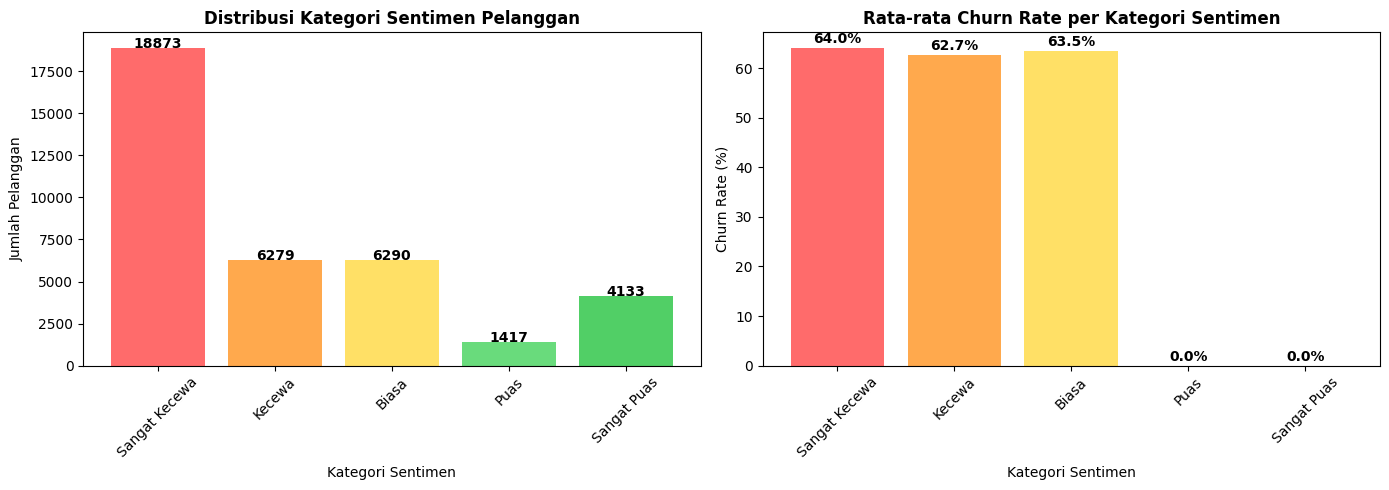


📈 Insight: Pelanggan dengan sentimen negatif cenderung memiliki churn rate lebih tinggi!


In [ ]:
# =============================================================================
# CELL 5: VISUALISASI DISTRIBUSI SENTIMEN
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi Kategori Sentimen
colors_sentiment = ['#FF6B6B', '#FFA94D', '#FFE066', '#69DB7C', '#51CF66']
sentiment_order = ['Sangat Kecewa', 'Kecewa', 'Biasa', 'Puas', 'Sangat Puas']

sentiment_counts = df['sentiment_kategori'].value_counts().reindex(sentiment_order, fill_value=0)

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors_sentiment)
axes[0].set_title('Distribusi Kategori Sentimen Pelanggan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kategori Sentimen')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].tick_params(axis='x', rotation=45)

# Tambahkan nilai di atas bar
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Plot 2: Sentimen vs Churn
sentiment_churn = df.groupby('sentiment_kategori')['churn'].mean().reindex(sentiment_order, fill_value=0) * 100

axes[1].bar(sentiment_churn.index, sentiment_churn.values, color=colors_sentiment)
axes[1].set_title('Rata-rata Churn Rate per Kategori Sentimen', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kategori Sentimen')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

# Tambahkan nilai di atas bar
for i, v in enumerate(sentiment_churn.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📈 Insight: Pelanggan dengan sentimen negatif cenderung memiliki churn rate lebih tinggi!")

In [ ]:
# =============================================================================
# CELL 6: ENCODING & SPLITTING DATA
# =============================================================================

# Simpan data untuk report sebelum encoding
df_for_report = df.copy()

# Ensure 'churn' column is numeric and handle NaNs if any
# Convert 'churn' to numeric, coercing errors to NaN
df['churn'] = pd.to_numeric(df['churn'], errors='coerce')

# Fill NaNs in 'churn' with the mode, but be careful if mode itself is NaN (i.e., all values are NaN)
if df['churn'].isnull().all():
    print("WARNING: The 'churn' column contains only NaN values after conversion. Setting all to 0.")
    df['churn'] = 0 # Default to 0 (Not Churn) if all are NaN
elif df['churn'].isnull().any():
    churn_mode = df['churn'].mode()[0]
    df['churn'] = df['churn'].fillna(churn_mode)
    print(f"INFO: Filled NaN values in 'churn' with mode: {int(churn_mode)}")

# 1. Encode kolom kategorikal
cat_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# 2. Definisikan X dan y
X = df.drop('churn', axis=1)
y = df['churn']

# Simpan nama fitur
feature_names = X.columns.tolist()

# 3. Split data (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Simpan index untuk report
test_indices = X_test.index.tolist()

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Encoding & Splitting Selesai!")
print(f"📊 Training set: {X_train_scaled.shape[0]} samples")
print(f"📊 Test set: {X_test_scaled.shape[0]} samples")
print(f"📋 Jumlah fitur: {X_train_scaled.shape[1]}")

✅ Data Encoding & Splitting Selesai!
📊 Training set: 29593 samples
📊 Test set: 7399 samples
📋 Jumlah fitur: 27


In [ ]:
# =============================================================================
# CELL 7: MODEL TRAINING (XGBoost)
# =============================================================================

# Inisialisasi model XGBoost
xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("🔄 Training model XGBoost...")
xgb_model.fit(X_train_scaled, y_train)
print("✅ Model training selesai!")

# Prediksi
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Prediksi untuk semua data (untuk report)
X_all_scaled = scaler.transform(X)
all_pred_proba = xgb_model.predict_proba(X_all_scaled)[:, 1]
all_pred = xgb_model.predict(X_all_scaled)

print(f"\n📊 Prediksi selesai untuk {len(all_pred)} pelanggan")

🔄 Training model XGBoost...
✅ Model training selesai!

📊 Prediksi selesai untuk 36992 pelanggan


In [ ]:
# =============================================================================
# CELL 8: TRAINING MODEL — LOGISTIC REGRESSION
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

print("🔄 Handling remaining NaNs for Logistic Regression...")
# Logistic Regression cannot handle NaNs. We use an imputer to fill any gaps.
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

print("🔄 Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_imputed, y_train)

# Prediksi
y_pred_lr       = lr_model.predict(X_test_imputed)
y_pred_proba_lr = lr_model.predict_proba(X_test_imputed)[:, 1]

print("✅ Logistic Regression selesai!")
print(f"   Training samples : {X_train_imputed.shape[0]}")
print(f"   Test samples     : {X_test_imputed.shape[0]}")

🔄 Handling remaining NaNs for Logistic Regression...
🔄 Training Logistic Regression...
✅ Logistic Regression selesai!
   Training samples : 29593
   Test samples     : 7399


In [ ]:
# =============================================================================
# CELL 9: TRAINING MODEL — RANDOM FOREST
# =============================================================================

from sklearn.ensemble import RandomForestClassifier

print("🔄 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf       = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Random Forest selesai!")
print(f"   Training samples : {X_train_scaled.shape[0]}")
print(f"   Test samples     : {X_test_scaled.shape[0]}")


🔄 Training Random Forest...


✅ Random Forest selesai!
   Training samples : 29593
   Test samples     : 7399


📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Not Churn       0.94      0.91      0.93      3396
       Churn       0.93      0.95      0.94      4003

    accuracy                           0.93      7399
   macro avg       0.93      0.93      0.93      7399
weighted avg       0.93      0.93      0.93      7399


🎯 ROC-AUC Score: 0.9751


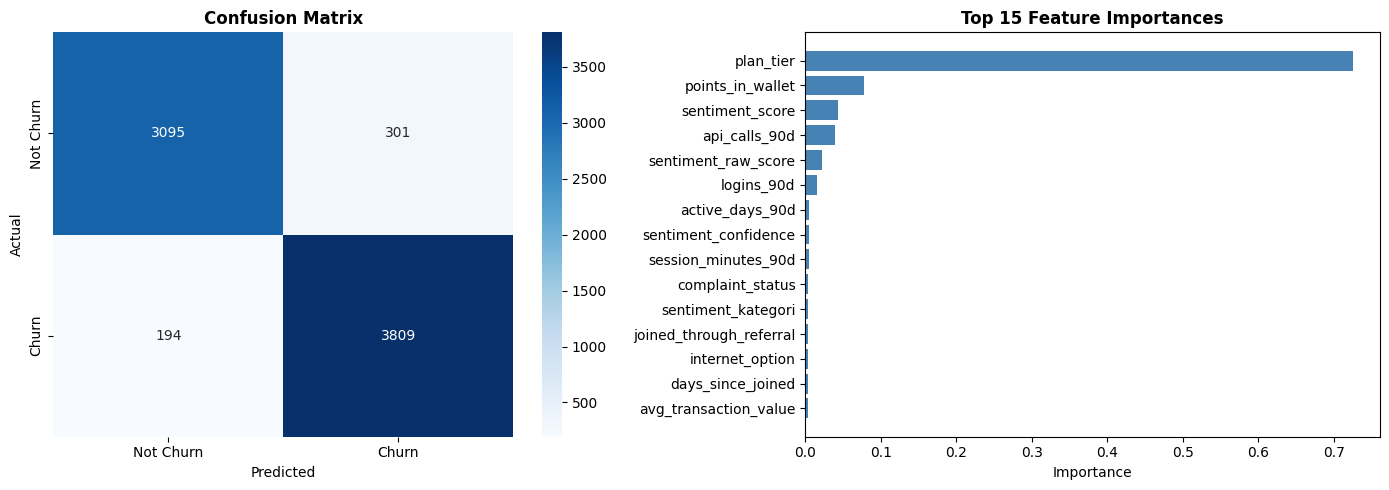

In [ ]:
# =============================================================================
# CELL 10: EVALUASI MODEL
# =============================================================================

# 1. Classification Report
print("=" * 60)
print("📊 CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Not Churn', 'Churn']))

# 2. ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n🎯 ROC-AUC Score: {roc_auc:.4f}")

# 3. Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature Importance (Top 15)
importances = xgb_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=True).tail(15)

axes[1].barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
axes[1].set_title('Top 15 Feature Importances', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# CELL 11: EVALUASI MODEL — LOGISTIC REGRESSION
# =============================================================================

from sklearn.metrics import classification_report, roc_auc_score

print("=" * 60)
print("📊 CLASSIFICATION REPORT — LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(y_test, y_pred_lr, target_names=["Not Churn", "Churn"]))

roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"🎯 ROC-AUC Score: {roc_auc_lr:.4f}")


📊 CLASSIFICATION REPORT — LOGISTIC REGRESSION
              precision    recall  f1-score   support

   Not Churn       0.84      0.90      0.87      3396
       Churn       0.91      0.85      0.88      4003

    accuracy                           0.87      7399
   macro avg       0.87      0.88      0.87      7399
weighted avg       0.88      0.87      0.87      7399

🎯 ROC-AUC Score: 0.9516


In [ ]:
# =============================================================================
# CELL 12: EVALUASI MODEL — RANDOM FOREST
# =============================================================================

from sklearn.metrics import classification_report, roc_auc_score

print("=" * 60)
print("📊 CLASSIFICATION REPORT — RANDOM FOREST")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=["Not Churn", "Churn"]))

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"🎯 ROC-AUC Score: {roc_auc_rf:.4f}")


📊 CLASSIFICATION REPORT — RANDOM FOREST
              precision    recall  f1-score   support

   Not Churn       0.91      0.94      0.93      3396
       Churn       0.95      0.92      0.94      4003

    accuracy                           0.93      7399
   macro avg       0.93      0.93      0.93      7399
weighted avg       0.93      0.93      0.93      7399

🎯 ROC-AUC Score: 0.9742


🔄 Menghitung SHAP values untuk XGBoost...
✅ SHAP values dihitung! Shape: (7399, 27)

📊 Plot 1: SHAP Beeswarm Summary Plot


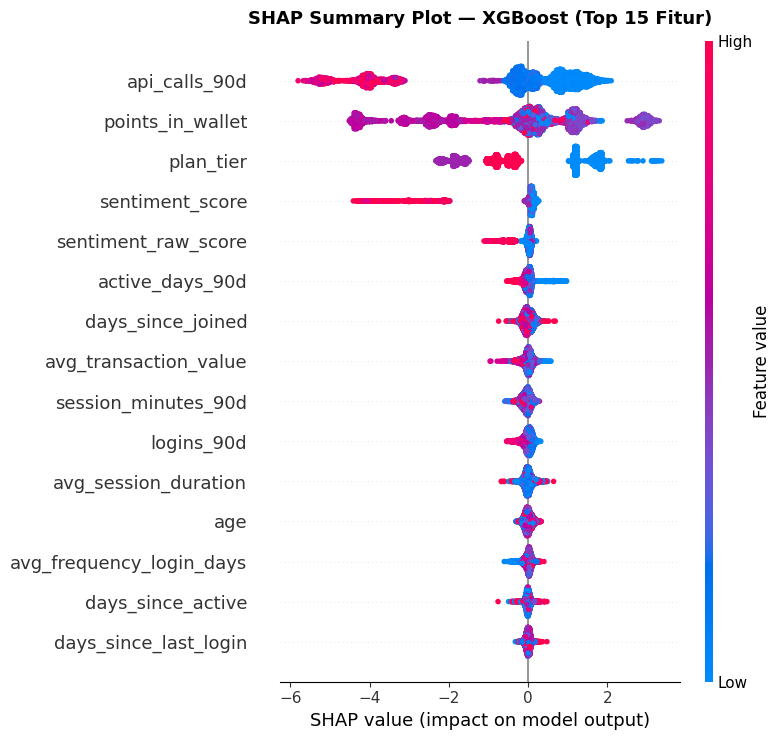


📊 Plot 2: SHAP Feature Importance (Mean |SHAP|)


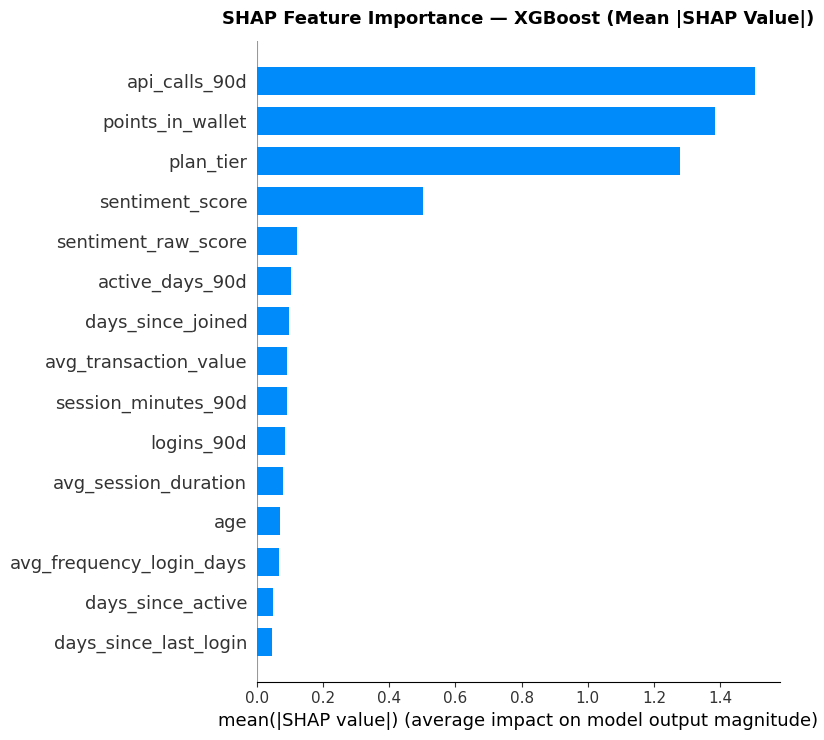


📊 Plot 3: Waterfall — Pelanggan risiko churn tertinggi


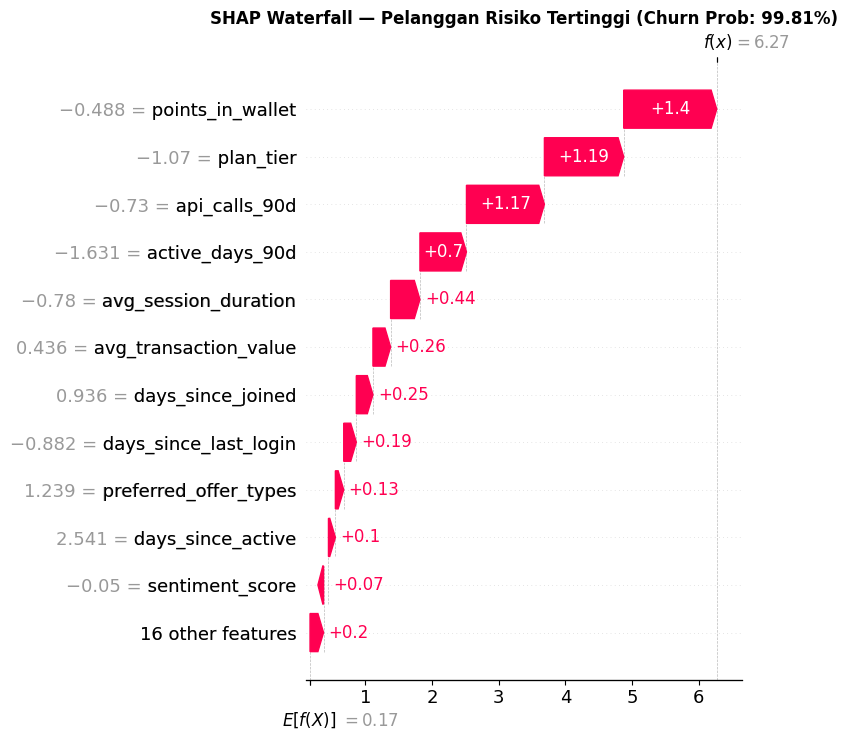


🔍 TOP 10 FITUR BERDASARKAN SHAP (XGBoost)
              Feature  Mean |SHAP|
        api_calls_90d     1.505851
     points_in_wallet     1.384580
            plan_tier     1.278925
      sentiment_score     0.502812
  sentiment_raw_score     0.121292
      active_days_90d     0.103779
    days_since_joined     0.095772
avg_transaction_value     0.091732
  session_minutes_90d     0.090439
           logins_90d     0.083542

✅ SHAP analysis selesai!


In [ ]:
# =============================================================================
# CELL 13: SHAP EXPLAINABILITY — XGBoost
# =============================================================================

import importlib, subprocess
if importlib.util.find_spec("shap") is None:
    print("📦 Installing shap...")
    subprocess.run(["pip", "install", "shap", "-q"], check=True)
    print("✅ shap installed!")

import shap
import pandas as pd
import matplotlib.pyplot as plt

print("🔄 Menghitung SHAP values untuk XGBoost...")
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)
X_test_df   = pd.DataFrame(X_test_scaled, columns=feature_names)
print(f"✅ SHAP values dihitung! Shape: {shap_values.shape}")

# ── Plot 1: Beeswarm Summary Plot ────────────────────────────────────────────
print("\n📊 Plot 1: SHAP Beeswarm Summary Plot")
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, plot_type="dot", max_display=15, show=False)
plt.title("SHAP Summary Plot — XGBoost (Top 15 Fitur)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# ── Plot 2: Bar Plot (Mean |SHAP|) ───────────────────────────────────────────
print("\n📊 Plot 2: SHAP Feature Importance (Mean |SHAP|)")
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_df, plot_type="bar", max_display=15, show=False)
plt.title("SHAP Feature Importance — XGBoost (Mean |SHAP Value|)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# ── Plot 3: Waterfall untuk pelanggan risiko tertinggi ───────────────────────
print("\n📊 Plot 3: Waterfall — Pelanggan risiko churn tertinggi")
high_risk_idx = y_pred_proba.argmax()
shap_explanation = shap.Explanation(
    values        = shap_values[high_risk_idx],
    base_values   = explainer.expected_value,
    data          = X_test_df.iloc[high_risk_idx].values,
    feature_names = feature_names
)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation, max_display=12, show=False)
plt.title(
    f"SHAP Waterfall — Pelanggan Risiko Tertinggi (Churn Prob: {y_pred_proba[high_risk_idx]:.2%})",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

# ── Tabel Top Fitur ───────────────────────────────────────────────────────────
mean_shap = pd.DataFrame({
    "Feature"    : feature_names,
    "Mean |SHAP|": abs(shap_values).mean(axis=0)
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

print("\n" + "="*50)
print("🔍 TOP 10 FITUR BERDASARKAN SHAP (XGBoost)")
print("="*50)
print(mean_shap.head(10).to_string(index=False))
print("="*50)
print("\n✅ SHAP analysis selesai!")


In [ ]:
# =============================================================================
# CELL 14: FUNGSI GENERATE PROBLEM & SOLUTION
# =============================================================================

def get_problem_and_solution(row, churn_prob, sentiment_kategori):
    """
    Fungsi untuk menentukan masalah dan solusi berdasarkan data pelanggan
    """
    problems = []
    solutions = []

    # 1. Analisis berdasarkan Churn Probability
    if churn_prob >= 0.7:
        problems.append("Risiko churn SANGAT TINGGI (>70%)")
        solutions.append("Prioritas tinggi: Hubungi pelanggan segera untuk retention program")
    elif churn_prob >= 0.5:
        problems.append("Risiko churn TINGGI (50-70%)")
        solutions.append("Tawarkan promo khusus atau loyalty reward")
    elif churn_prob >= 0.3:
        problems.append("Risiko churn SEDANG (30-50%)")
        solutions.append("Monitor aktivitas dan kirim engagement email")

    # 2. Analisis berdasarkan Sentimen
    if sentiment_kategori == 'Sangat Kecewa':
        problems.append("Pelanggan sangat tidak puas dengan layanan")
        solutions.append("Eskalasi ke tim customer success untuk penanganan personal")
    elif sentiment_kategori == 'Kecewa':
        problems.append("Pelanggan menunjukkan ketidakpuasan")
        solutions.append("Kirim survey untuk identifikasi keluhan spesifik")

    # 3. Analisis berdasarkan data lainnya (jika ada)
    # Contoh: cek kolom complaint, points_in_wallet, dll
    try:
        if 'complaint_status' in row.index and row.get('complaint_status', 0) == 1:
            problems.append("Ada keluhan yang belum terselesaikan")
            solutions.append("Prioritaskan penyelesaian keluhan pelanggan")

        if 'points_in_wallet' in row.index and row.get('points_in_wallet', 0) > 500:
            solutions.append("Ingatkan pelanggan untuk redeem points yang tersedia")

        if 'days_since_joined' in row.index:
            days = row.get('days_since_joined', 0)
            if days > 365:
                solutions.append("Berikan loyalty bonus untuk pelanggan setia")
    except:
        pass

    # Default jika tidak ada masalah
    if not problems:
        problems.append("Tidak ada masalah signifikan terdeteksi")
        solutions.append("Pertahankan kualitas layanan dan engagement rutin")

    return "; ".join(problems), "; ".join(solutions)

def get_sentiment_conclusion(sentiment_kategori, sentiment_score, churn_prob):
    """
    Fungsi untuk membuat kesimpulan sentimen pelanggan
    """
    if sentiment_kategori == 'Sangat Puas':
        conclusion = f"Pelanggan SANGAT PUAS dengan layanan (Score: {sentiment_score}/5). "
        if churn_prob < 0.3:
            conclusion += "Kemungkinan menjadi brand advocate."
        else:
            conclusion += "Namun perlu monitoring karena ada faktor risiko lain."

    elif sentiment_kategori == 'Puas':
        conclusion = f"Pelanggan PUAS dengan layanan (Score: {sentiment_score}/5). "
        if churn_prob < 0.3:
            conclusion += "Potensi untuk ditingkatkan menjadi loyal customer."
        else:
            conclusion += "Ada faktor lain yang perlu diperhatikan."

    elif sentiment_kategori == 'Biasa':
        conclusion = f"Pelanggan NETRAL/BIASA (Score: {sentiment_score}/5). "
        conclusion += "Perlu upaya untuk meningkatkan engagement dan kepuasan."

    elif sentiment_kategori == 'Kecewa':
        conclusion = f"Pelanggan KECEWA dengan layanan (Score: {sentiment_score}/5). "
        conclusion += "PERHATIAN: Perlu tindakan untuk memperbaiki pengalaman pelanggan."

    else:  # Sangat Kecewa
        conclusion = f"Pelanggan SANGAT KECEWA (Score: {sentiment_score}/5). "
        conclusion += "URGENT: Butuh penanganan segera untuk mencegah churn!"

    return conclusion

print("✅ Fungsi Problem & Solution berhasil dibuat!")

✅ Fungsi Problem & Solution berhasil dibuat!


In [ ]:
# =============================================================================
# CELL 15: GENERATE COMPREHENSIVE REPORT DATAFRAME
# =============================================================================

print("🔄 Generating comprehensive report...")

# Buat DataFrame untuk report
report_df = pd.DataFrame()

# 1. Informasi Identitas (dari data original jika ada)
if 'customer_id' in df_original.columns:
    report_df['Customer_ID'] = df_original['customer_id']
else:
    report_df['Customer_ID'] = [f"CUST_{str(i).zfill(5)}" for i in range(len(df))]

if 'Name' in df_original.columns:
    report_df['Nama'] = df_original['Name']
elif 'name' in df_original.columns:
    report_df['Nama'] = df_original['name']
else:
    report_df['Nama'] = [f"Customer {i+1}" for i in range(len(df))]

# 2. Data Gender dan Region (jika ada)
for col in ['gender', 'region', 'membership_category']:
    if col in df_original.columns:
        report_df[col.replace('_', ' ').title()] = df_original[col]

# 3. Churn Probability
report_df['Churn_Probability'] = all_pred_proba
report_df['Churn_Probability_Percent'] = (all_pred_proba * 100).round(2)
report_df['Predicted_Churn'] = ['Ya' if p == 1 else 'Tidak' for p in all_pred]
report_df['Actual_Churn'] = ['Ya' if c == 1 else 'Tidak' for c in y.values]

# 4. Risk Level
def get_risk_level(prob):
    if prob >= 0.7:
        return 'TINGGI'
    elif prob >= 0.5:
        return 'SEDANG-TINGGI'
    elif prob >= 0.3:
        return 'SEDANG'
    else:
        return 'RENDAH'

report_df['Risk_Level'] = report_df['Churn_Probability'].apply(get_risk_level)

# 5. Sentiment Analysis Results
report_df['Sentiment_Kategori'] = df_for_report['sentiment_kategori']
report_df['Sentiment_Score'] = df_for_report['sentiment_score']
report_df['Sentiment_Confidence'] = (df_for_report['sentiment_confidence'] * 100).round(2)

# 6. Original Feedback
report_df['Feedback_Original'] = feedback_data.values

# 7. Problem, Solution, dan Kesimpulan
problems_list = []
solutions_list = []
conclusions_list = []

for idx in range(len(report_df)):
    row = df_for_report.iloc[idx]
    churn_prob = report_df['Churn_Probability'].iloc[idx]
    sentiment_kat = report_df['Sentiment_Kategori'].iloc[idx]
    sentiment_score = report_df['Sentiment_Score'].iloc[idx]

    problem, solution = get_problem_and_solution(row, churn_prob, sentiment_kat)
    conclusion = get_sentiment_conclusion(sentiment_kat, sentiment_score, churn_prob)

    problems_list.append(problem)
    solutions_list.append(solution)
    conclusions_list.append(conclusion)

report_df['Masalah'] = problems_list
report_df['Solusi'] = solutions_list
report_df['Kesimpulan_Sentiment'] = conclusions_list

print(f"✅ Report DataFrame berhasil dibuat dengan {len(report_df)} baris!")
print(f"📋 Kolom: {report_df.columns.tolist()}")
report_df.head()

🔄 Generating comprehensive report...
✅ Report DataFrame berhasil dibuat dengan 36992 baris!
📋 Kolom: ['Customer_ID', 'Nama', 'Gender', 'Churn_Probability', 'Churn_Probability_Percent', 'Predicted_Churn', 'Actual_Churn', 'Risk_Level', 'Sentiment_Kategori', 'Sentiment_Score', 'Sentiment_Confidence', 'Feedback_Original', 'Masalah', 'Solusi', 'Kesimpulan_Sentiment']


,Customer_ID,Nama,Gender,Churn_Probability,Churn_Probability_Percent,Predicted_Churn,Actual_Churn,Risk_Level,Sentiment_Kategori,Sentiment_Score,Sentiment_Confidence,Feedback_Original,Masalah,Solusi,Kesimpulan_Sentiment
0,CUST_00000,Customer 1,F,0.000084,0.010000,Tidak,Tidak,RENDAH,Sangat Puas,5,87.9,Products always in Stock,Tidak ada masalah signifikan terdeteksi,Ingatkan pelanggan untuk redeem points yang te...,Pelanggan SANGAT PUAS dengan layanan (Score: 5...
1,CUST_00001,Customer 2,F,0.000108,0.010000,Tidak,Tidak,RENDAH,Sangat Puas,5,91.8,Quality Customer Care,Tidak ada masalah signifikan terdeteksi,Ingatkan pelanggan untuk redeem points yang te...,Pelanggan SANGAT PUAS dengan layanan (Score: 5...
2,CUST_00002,Customer 3,F,0.974817,97.480003,Ya,Ya,TINGGI,Sangat Kecewa,1,100.0,Poor Website,Risiko churn SANGAT TINGGI (>70%); Pelanggan s...,Prioritas tinggi: Hubungi pelanggan segera unt...,Pelanggan SANGAT KECEWA (Score: 1/5). URGENT: ...
3,CUST_00003,Customer 4,M,0.961478,96.150002,Ya,Ya,TINGGI,Sangat Kecewa,1,100.0,Poor Website,Risiko churn SANGAT TINGGI (>70%); Pelanggan s...,Prioritas tinggi: Hubungi pelanggan segera unt...,Pelanggan SANGAT KECEWA (Score: 1/5). URGENT: ...
4,CUST_00004,Customer 5,F,0.954568,95.459999,Ya,Ya,TINGGI,Sangat Kecewa,1,100.0,Poor Website,Risiko churn SANGAT TINGGI (>70%); Pelanggan s...,Prioritas tinggi: Hubungi pelanggan segera unt...,Pelanggan SANGAT KECEWA (Score: 1/5). URGENT: ...


In [ ]:
# =============================================================================
# CELL 16: PREVIEW REPORT
# =============================================================================

# Tampilkan sample report
print("=" * 80)
print("📋 PREVIEW REPORT - 5 PELANGGAN DENGAN RISIKO TERTINGGI")
print("=" * 80)

high_risk = report_df.nlargest(5, 'Churn_Probability')

for idx, row in high_risk.iterrows():
    print(f"\n{'─' * 60}")
    print(f"👤 {row['Customer_ID']} | {row.get('Nama', 'N/A')}")
    print(f"{'─' * 60}")
    print(f"📊 Churn Probability: {row['Churn_Probability_Percent']}%")
    print(f"⚠️  Risk Level: {row['Risk_Level']}")
    print(f"😊 Sentimen: {row['Sentiment_Kategori']} (Score: {row['Sentiment_Score']}/5)")
    print(f"💬 Feedback: {row['Feedback_Original'][:100]}..." if len(str(row['Feedback_Original'])) > 100 else f"💬 Feedback: {row['Feedback_Original']}")
    print(f"\n❌ MASALAH: {row['Masalah']}")
    print(f"✅ SOLUSI: {row['Solusi']}")
    print(f"\n📝 KESIMPULAN: {row['Kesimpulan_Sentiment']}")

print(f"\n{'=' * 80}")

📋 PREVIEW REPORT - 5 PELANGGAN DENGAN RISIKO TERTINGGI

────────────────────────────────────────────────────────────
👤 CUST_30985 | Customer 30986
────────────────────────────────────────────────────────────
📊 Churn Probability: 99.87999725341797%
⚠️  Risk Level: TINGGI
😊 Sentimen: Biasa (Score: 3/5)
💬 Feedback: No reason specified

❌ MASALAH: Risiko churn SANGAT TINGGI (>70%)
✅ SOLUSI: Prioritas tinggi: Hubungi pelanggan segera untuk retention program

📝 KESIMPULAN: Pelanggan NETRAL/BIASA (Score: 3/5). Perlu upaya untuk meningkatkan engagement dan kepuasan.

────────────────────────────────────────────────────────────
👤 CUST_02998 | Customer 2999
────────────────────────────────────────────────────────────
📊 Churn Probability: 99.83000183105469%
⚠️  Risk Level: TINGGI
😊 Sentimen: Sangat Kecewa (Score: 1/5)
💬 Feedback: Poor Product Quality

❌ MASALAH: Risiko churn SANGAT TINGGI (>70%); Pelanggan sangat tidak puas dengan layanan
✅ SOLUSI: Prioritas tinggi: Hubungi pelanggan segera untuk

In [ ]:
# =============================================================================
# CELL 17: EXPORT TO EXCEL DENGAN FORMATTING
# =============================================================================

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.chart import BarChart, PieChart, Reference
import os

def export_to_excel(report_df, filename='Churn_Analysis_Report.xlsx'):
    """
    Export report ke Excel dengan formatting yang rapi
    """

    # Buat workbook baru
    wb = Workbook()

    # =========================================================================
    # SHEET 1: SUMMARY
    # =========================================================================
    ws_summary = wb.active
    ws_summary.title = "Summary"

    # Header styling
    header_font = Font(bold=True, color='FFFFFF', size=12)
    header_fill = PatternFill(start_color='4472C4', end_color='4472C4', fill_type='solid')

    # Summary Statistics
    ws_summary['A1'] = "CHURN ANALYSIS REPORT"
    ws_summary['A1'].font = Font(bold=True, size=18)
    ws_summary['A2'] = f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"

    # Overall Statistics
    total_customers = len(report_df)
    total_high_risk = len(report_df[report_df['Risk_Level'] == 'TINGGI'])
    total_medium_risk = len(report_df[report_df['Risk_Level'].isin(['SEDANG', 'SEDANG-TINGGI'])])
    avg_churn_prob = report_df['Churn_Probability_Percent'].mean()

    stats = [
        ['STATISTIK UMUM', ''],
        ['Total Pelanggan', total_customers],
        ['Pelanggan Risiko Tinggi', total_high_risk],
        ['Pelanggan Risiko Sedang', total_medium_risk],
        ['Rata-rata Churn Probability', f"{avg_churn_prob:.2f}%"],
        ['', ''],
        ['DISTRIBUSI SENTIMEN', ''],
    ]

    # Tambahkan distribusi sentimen
    sentiment_dist = report_df['Sentiment_Kategori'].value_counts()
    for sent, count in sentiment_dist.items():
        stats.append([sent, count])

    for row_idx, (label, value) in enumerate(stats, start=4):
        ws_summary[f'A{row_idx}'] = label
        ws_summary[f'B{row_idx}'] = value
        if label in ['STATISTIK UMUM', 'DISTRIBUSI SENTIMEN']:
            ws_summary[f'A{row_idx}'].font = Font(bold=True, size=11)

    # =========================================================================
    # SHEET 2: FULL REPORT
    # =========================================================================
    ws_report = wb.create_sheet("Full Report")

    # Tulis header
    headers = report_df.columns.tolist()
    for col_idx, header in enumerate(headers, start=1):
        cell = ws_report.cell(row=1, column=col_idx, value=header)
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = Alignment(horizontal='center', vertical='center')

    # Tulis data
    for row_idx, row in enumerate(report_df.values, start=2):
        for col_idx, value in enumerate(row, start=1):
            cell = ws_report.cell(row=row_idx, column=col_idx, value=value)
            cell.alignment = Alignment(horizontal='left', vertical='center', wrap_text=True)

    # Conditional formatting untuk Risk Level
    risk_fills = {
        'TINGGI': PatternFill(start_color='FF6B6B', end_color='FF6B6B', fill_type='solid'),
        'SEDANG-TINGGI': PatternFill(start_color='FFA94D', end_color='FFA94D', fill_type='solid'),
        'SEDANG': PatternFill(start_color='FFE066', end_color='FFE066', fill_type='solid'),
        'RENDAH': PatternFill(start_color='69DB7C', end_color='69DB7C', fill_type='solid')
    }

    risk_col_idx = headers.index('Risk_Level') + 1
    for row_idx in range(2, len(report_df) + 2):
        cell = ws_report.cell(row=row_idx, column=risk_col_idx)
        if cell.value in risk_fills:
            cell.fill = risk_fills[cell.value]

    # Conditional formatting untuk Sentiment
    sentiment_fills = {
        'Sangat Kecewa': PatternFill(start_color='FF6B6B', end_color='FF6B6B', fill_type='solid'),
        'Kecewa': PatternFill(start_color='FFA94D', end_color='FFA94D', fill_type='solid'),
        'Biasa': PatternFill(start_color='FFE066', end_color='FFE066', fill_type='solid'),
        'Puas': PatternFill(start_color='69DB7C', end_color='69DB7C', fill_type='solid'),
        'Sangat Puas': PatternFill(start_color='51CF66', end_color='51CF66', fill_type='solid')
    }

    sentiment_col_idx = headers.index('Sentiment_Kategori') + 1
    for row_idx in range(2, len(report_df) + 2):
        cell = ws_report.cell(row=row_idx, column=sentiment_col_idx)
        if cell.value in sentiment_fills:
            cell.fill = sentiment_fills[cell.value]

    # Adjust column widths
    column_widths = {
        'Customer_ID': 15,
        'Nama': 20,
        'Churn_Probability_Percent': 12,
        'Risk_Level': 15,
        'Sentiment_Kategori': 15,
        'Feedback_Original': 50,
        'Masalah': 50,
        'Solusi': 60,
        'Kesimpulan_Sentiment': 70
    }

    for col_idx, header in enumerate(headers, start=1):
        width = column_widths.get(header, 15)
        ws_report.column_dimensions[ws_report.cell(row=1, column=col_idx).column_letter].width = width

    # =========================================================================
    # SHEET 3: HIGH RISK CUSTOMERS
    # =========================================================================
    ws_high_risk = wb.create_sheet("High Risk Customers")

    high_risk_df = report_df[report_df['Risk_Level'] == 'TINGGI'].copy()

    # Tulis header
    for col_idx, header in enumerate(headers, start=1):
        cell = ws_high_risk.cell(row=1, column=col_idx, value=header)
        cell.font = header_font
        cell.fill = PatternFill(start_color='C00000', end_color='C00000', fill_type='solid')
        cell.alignment = Alignment(horizontal='center')

    # Tulis data
    for row_idx, row in enumerate(high_risk_df.values, start=2):
        for col_idx, value in enumerate(row, start=1):
            cell = ws_high_risk.cell(row=row_idx, column=col_idx, value=value)

    # =========================================================================
    # SHEET 4: ACTION ITEMS
    # =========================================================================
    ws_actions = wb.create_sheet("Action Items")

    ws_actions['A1'] = "ACTION ITEMS - PRIORITAS TINGGI"
    ws_actions['A1'].font = Font(bold=True, size=14)

    action_headers = ['Customer_ID', 'Nama', 'Churn_Prob%', 'Sentimen', 'Masalah', 'Solusi Rekomendasi']
    for col_idx, header in enumerate(action_headers, start=1):
        cell = ws_actions.cell(row=3, column=col_idx, value=header)
        cell.font = header_font
        cell.fill = PatternFill(start_color='ED7D31', end_color='ED7D31', fill_type='solid')

    # Filter high risk dan negative sentiment
    priority_df = report_df[
        (report_df['Churn_Probability'] >= 0.5) |
        (report_df['Sentiment_Kategori'].isin(['Sangat Kecewa', 'Kecewa']))
    ].sort_values('Churn_Probability', ascending=False)

    for row_idx, (_, row) in enumerate(priority_df.iterrows(), start=4):
        ws_actions.cell(row=row_idx, column=1, value=row['Customer_ID'])
        ws_actions.cell(row=row_idx, column=2, value=row.get('Nama', 'N/A'))
        ws_actions.cell(row=row_idx, column=3, value=row['Churn_Probability_Percent'])
        ws_actions.cell(row=row_idx, column=4, value=row['Sentiment_Kategori'])
        ws_actions.cell(row=row_idx, column=5, value=row['Masalah'])
        ws_actions.cell(row=row_idx, column=6, value=row['Solusi'])

    # Adjust widths
    for col_idx, width in enumerate([15, 20, 12, 15, 50, 60], start=1):
        ws_actions.column_dimensions[ws_actions.cell(row=1, column=col_idx).column_letter].width = width

    # Simpan file
    wb.save(filename)
    print(f"✅ Report berhasil disimpan: {filename}")
    return filename

# Export report
excel_filename = export_to_excel(report_df, 'Churn_Analysis_Report.xlsx')

✅ Report berhasil disimpan: Churn_Analysis_Report.xlsx
